<a href="https://colab.research.google.com/github/Sayara20/LimpiezaDatos/blob/main/PrecioTazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from transformers import pipeline
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import unicodedata
import re
import nltk


In [ ]:
#CArgar archivo
df = pd.read_csv("PrecioTazas.csv",encoding='utf-8')
df.head()

,comentario,likesCount
0,Yo las doy en $65 🥹 creo que las subiré un poq...,33
1,Yo en diciembre las di en $10 Dlls o $180 pesos,10
2,Yo los doy en $130 y $150 depende mi estado de...,15
3,Pregunta cuanto le ponen los parametros a los...,0
4,Y esos ya sublimados en cuantos los dan?.. Ape...,0


In [ ]:
df.shape

(55, 2)

In [ ]:
df['Precio'] = df['comentario'].str.extract(r'(\d+\.\d+|\d+)').astype(float)
df.head()

,comentario,likesCount,Precio
0,Yo las doy en $65 🥹 creo que las subiré un poq...,33,65.0
1,Yo en diciembre las di en $10 Dlls o $180 pesos,10,10.0
2,Yo los doy en $130 y $150 depende mi estado de...,15,130.0
3,Pregunta cuanto le ponen los parametros a los...,0,NaN
4,Y esos ya sublimados en cuantos los dan?.. Ape...,0,NaN


In [ ]:
def extraer_todos_los_numeros(columna):
    # \d+ busca uno o más dígitos seguidos
    return columna.str.findall(r'\d+')

In [ ]:
df['Precio2'] = extraer_todos_los_numeros(df['comentario'])
df.head()

,comentario,likesCount,Precio,Precio2
0,Yo las doy en $65 🥹 creo que las subiré un poq...,33,65.0,[65]
1,Yo en diciembre las di en $10 Dlls o $180 pesos,10,10.0,"[10, 180]"
2,Yo los doy en $130 y $150 depende mi estado de...,15,130.0,"[130, 150]"
3,Pregunta cuanto le ponen los parametros a los...,0,NaN,[]
4,Y esos ya sublimados en cuantos los dan?.. Ape...,0,NaN,[]


In [ ]:
#elimina  valores vacios
df_copy = df.dropna(subset=['Precio'])
df_copy.head()

,comentario,likesCount,Precio,Precio2
0,Yo las doy en $65 🥹 creo que las subiré un poq...,33,65.0,[65]
1,Yo en diciembre las di en $10 Dlls o $180 pesos,10,10.0,"[10, 180]"
2,Yo los doy en $130 y $150 depende mi estado de...,15,130.0,"[130, 150]"
5,Acá en mi ciudad los serigrafistas las dan en ...,0,100.0,"[100, 50]"
7,Yo en 100 con blister,1,100.0,[100]


In [ ]:
df_copy.shape

(40, 4)

In [ ]:
#filtramos precios mayores a $30
df_copy = df_copy[df_copy['Precio'] > 30]
df_copy.head()

,comentario,likesCount,Precio,Precio2
0,Yo las doy en $65 🥹 creo que las subiré un poq...,33,65.0,[65]
2,Yo los doy en $130 y $150 depende mi estado de...,15,130.0,"[130, 150]"
5,Acá en mi ciudad los serigrafistas las dan en ...,0,100.0,"[100, 50]"
7,Yo en 100 con blister,1,100.0,[100]
9,"Yo las doy en $130 con porta taza, $100 solo l...",1,130.0,"[130, 100]"


In [ ]:
df_copy.shape


(36, 4)

In [ ]:
df_copy[['Precio']].describe()

,Precio
count,36.000000
mean,122.361111
std,37.176915
min,60.000000
25%,100.000000
50%,120.000000
75%,146.250000
max,200.000000


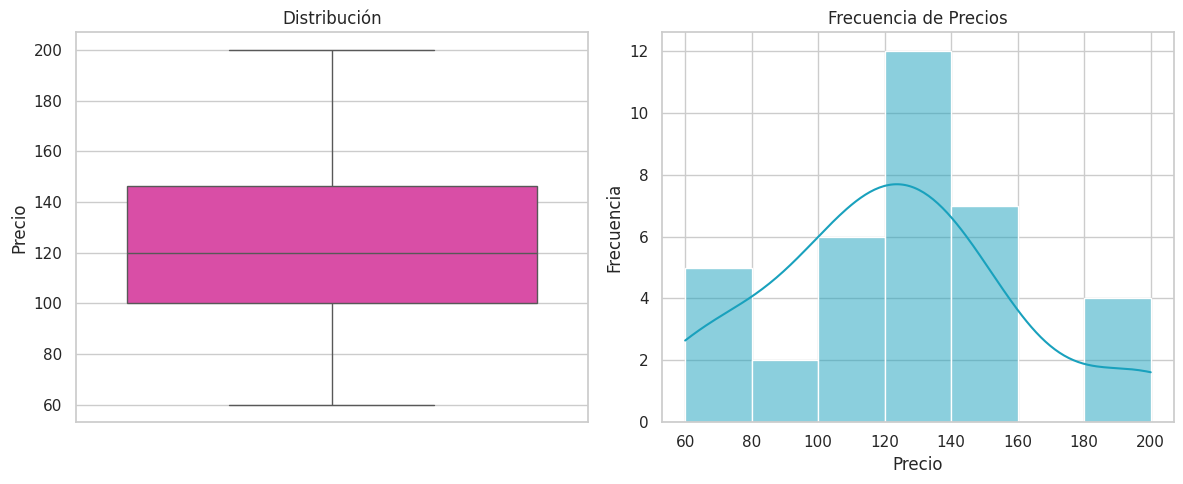

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo
sns.set_theme(style="whitegrid")

# Crear una figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Boxplot - Ideal para ver los cuartiles (25%, 50%, 75%)
sns.boxplot(y=df_copy['Precio'], ax=axes[0], color='#f037ac')
axes[0].set_title('Distribución')
axes[0].set_ylabel('Precio')

# 2. Histograma - Ideal para ver la frecuencia de los precios
sns.histplot(df_copy['Precio'], kde=True, ax=axes[1], color='#19a1bd')
axes[1].set_title('Frecuencia de Precios')
axes[1].set_xlabel('Precio')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

# 1. Guardar el DataFrame en el entorno de Colab
df_copy.to_csv('precioDatosLimpios.xlsx', index=False)

# 2. Descargar el archivo a tu ordenador
files.download('precioDatosLimpios.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

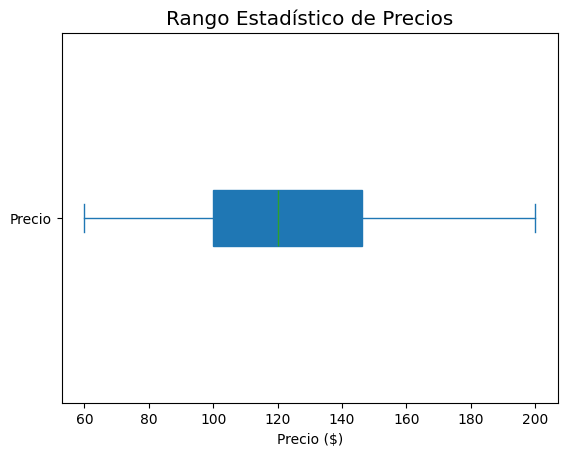

In [ ]:
df_copy['Precio'].plot(kind='box', vert=False, patch_artist=True)

plt.style.use('ggplot') # O puedes usar 'seaborn'
plt.title('Rango Estadístico de Precios')
plt.xlabel('Precio ($)')
plt.show()

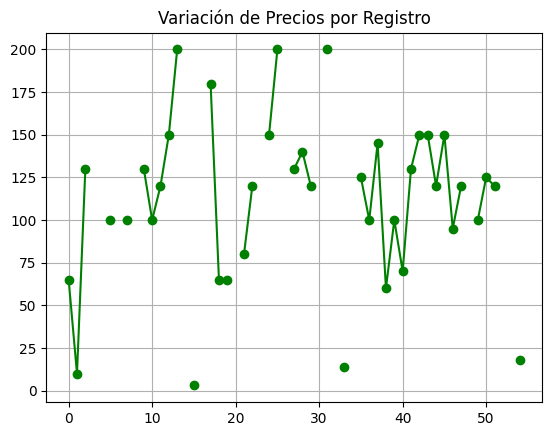

In [ ]:
df['Precio'].plot(kind='line', marker='o', linestyle='-', color='green')

plt.title('Variación de Precios por Registro')
plt.grid(True)
plt.show()

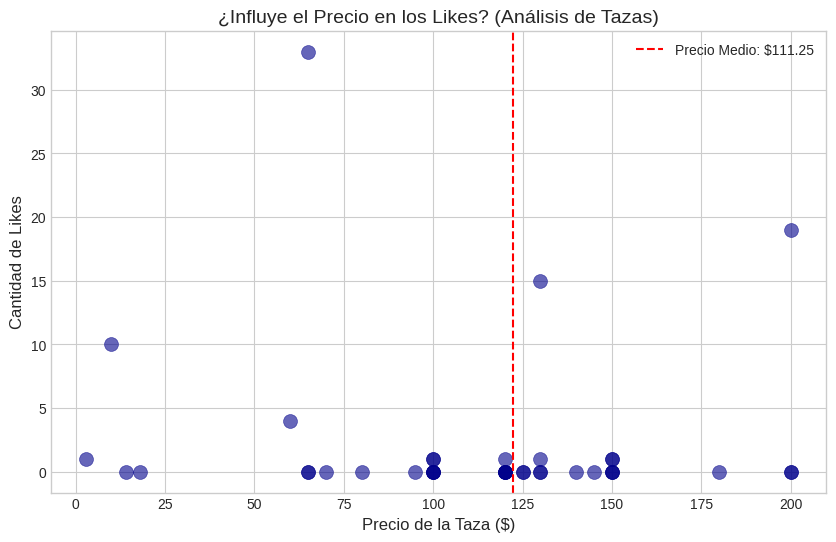

In [ ]:
# Configuramos el estilo
plt.style.use('seaborn-v0_8-whitegrid')

# Creamos el gráfico de dispersión
df.plot(kind='scatter', x='Precio', y='likesCount',
        alpha=0.6, s=100, c='darkblue', figsize=(10, 6))

# Personalización
plt.title('¿Influye el Precio en los Likes? (Análisis de Tazas)', fontsize=14)
plt.xlabel('Precio de la Taza ($)', fontsize=12)
plt.ylabel('Cantidad de Likes', fontsize=12)

# Añadimos una línea de promedio de precio para referencia
plt.axvline(df_copy['Precio'].mean(), color='red', linestyle='--', label=f'Precio Medio: ${df["Precio"].mean():.2f}')
plt.legend()

plt.show()

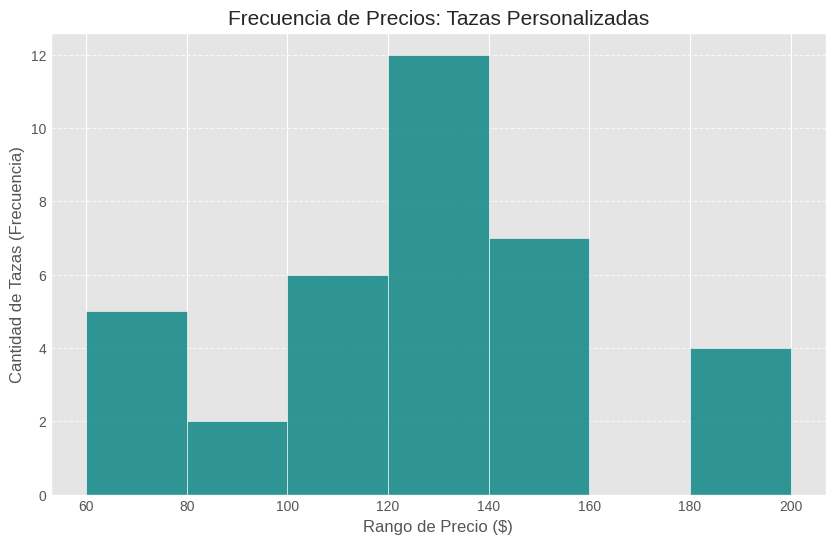

In [ ]:


# Configuramos el estilo para que se vea profesional
plt.style.use('ggplot')

plt.figure(figsize=(10, 6))

# bins=7 divide el rango de 60 a 200 en grupos lógicos
df_copy['Precio'].plot(kind='hist', bins=7, color='teal', edgecolor='white', alpha=0.8)

# Personalización de la gráfica
plt.title('Frecuencia de Precios: Tazas Personalizadas', fontsize=15)
plt.xlabel('Rango de Precio ($)', fontsize=12)
plt.ylabel('Cantidad de Tazas (Frecuencia)', fontsize=12)

# Añadimos una cuadrícula horizontal para facilitar la lectura
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

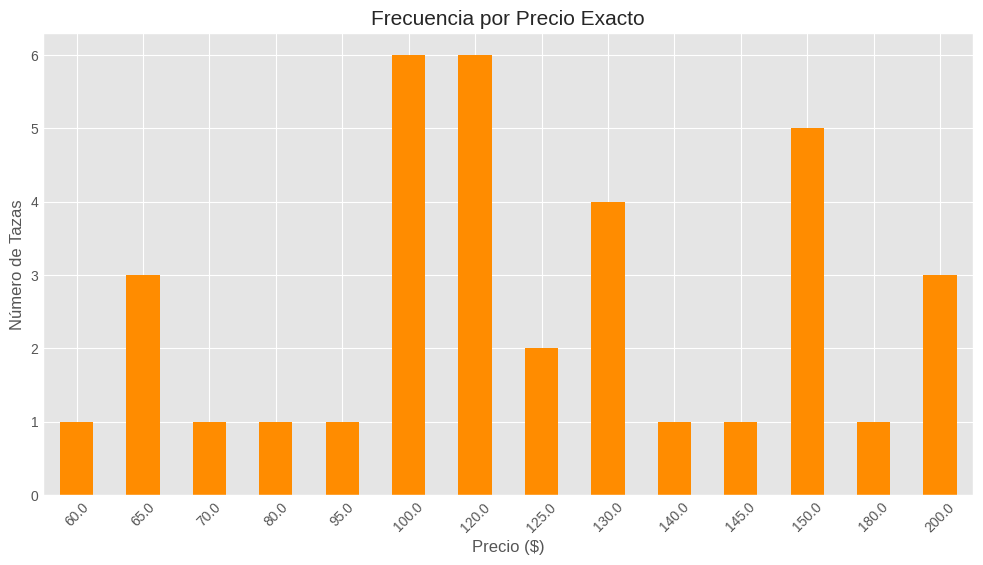

In [ ]:
plt.figure(figsize=(12, 6))

# Contamos cuántas veces aparece cada precio y ordenamos por precio
df_copy['Precio'].value_counts().sort_index().plot(kind='bar', color='darkorange')

plt.title('Frecuencia por Precio Exacto', fontsize=15)
plt.xlabel('Precio ($)', fontsize=12)
plt.ylabel('Número de Tazas', fontsize=12)
plt.xticks(rotation=45)

plt.show()